## Test the spline derivative function


In [28]:
import numpy as np
from lisaconstants import ASTRONOMICAL_YEAR 
YRSID_SI = ASTRONOMICAL_YEAR # alias
T_OBS = 2.0
N_PTS = 1262
Tpls = np.linspace(0, T_OBS, N_PTS)
t_alpha = np.linspace(0.0, T_OBS * YRSID_SI, N_PTS)

Federico needs the spline derivatives on this grid `t_alpha` for a fixed duration, so need to integrate backwards from the end of the inspiral. The function below does this, and returns the frequency and its derivatives on the `t_alpha` grid.
```python
def get_f_fdot_fddot_back(params, t_alpha):
    m1, m2, a, ef, Tpl = params
    x0 = 1.0
    rhs.add_fixed_parameters(m1, m2, a)
    p_0 = traj.inspiral_generator.func.separatrix_buffer_dist + get_separatrix(a, ef, x0) + 1e-6
    traj(m1, m2, a, p_0, ef, x0, T=Tpl, integrate_backwards=True, err=1e-11)

    T = np.min([Tpl, t_alpha[-1] / YRSID_SI])
    new_t_alpha = (t_alpha + YRSID_SI * T - t_alpha[-1])[::-1]
    mask = (new_t_alpha > 0.0)

    f = np.zeros((2, t_alpha.shape[0]))
    f_ = traj.inspiral_generator.eval_integrator_derivative_spline(new_t_alpha[mask], order=1)
    f[0][mask] = -f_[:, 3] / (np.pi * 2)
    f[1][mask] = -f_[:, 5] / (np.pi * 2)
    return f
``` 
TODO: extend this to the JAX implementation and compare results

In [29]:

import os

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import diffrax
import numpy as np
import pprint

from fewtrax.data.loader import load_flux_data
from fewtrax.trajectory.inspiral import EMRIInspiral, _x_sign, SEPARATRIX_BUFFER
from fewtrax.utils.constants import MTSUN_SI, YEAR_SI
from fewtrax.utils.geodesic import get_separatrix_fast, get_fundamental_frequencies_platform


In [30]:

# Params
M= 1e6 
mu= 10.0 
a = 0.5 
e_f =0.1
T_OBS = 2.0   # years
x0 = 1.0


In [31]:

from dotenv import load_dotenv
load_dotenv()
DATA_DIR = os.getenv("FEW_DATA_DIR")
print(f"FEW_DATA_DIR = {DATA_DIR}")
flux_data = load_flux_data()
traj = EMRIInspiral(flux_data, phases=True)


FEW_DATA_DIR = /Users/bertd/Documents/PhD/LISA/Codes/FastEMRIWaveforms/src/few/data


In [32]:
# conversiosn
a_   = jnp.asarray(a,  dtype=jnp.float64)
e_f_ = jnp.asarray(e_f, dtype=jnp.float64)
M_s  = (M + mu) * MTSUN_SI                         # total mass in seconds
T_s  = T_OBS * YEAR_SI                             # observation time [s]
T_geo = T_s / M_s                                  # geometric time [M]
mu_over_M = M * mu / (M + mu)**2                   # symmetric mass ratio η
r_isco = get_separatrix_fast(jnp.abs(a_), jnp.zeros((), jnp.float64), _x_sign(a_, x0))


In [33]:

# Initial conditions: start at separatrix (backward integration moves away from it)
p_sep   = get_separatrix_fast(jnp.abs(a_), e_f_, _x_sign(a_, x0))
p_start = p_sep + SEPARATRIX_BUFFER
y0      = jnp.array([p_start, e_f_, 0.0, 0.0, 0.0], dtype=jnp.float64)
ode_args = (jnp.asarray(mu_over_M), a_, x0, r_isco)


In [34]:
# new function for backwards ODE RHS TODO add this to ode object
def ode_rhs_bwd(t, y, args):
    return -traj._ode_rhs(t, y, args)

# Definine time axis on which we want to save solution
N_pts   = 200
t_save  = jnp.linspace(0.0, T_geo, N_pts, dtype=jnp.float64)


In [35]:
# solve the ODEs backwards in time and save solutionn at specified times
sol_ts = diffrax.diffeqsolve(
    diffrax.ODETerm(ode_rhs_bwd),
    diffrax.Dopri8(),
    t0=jnp.zeros((), jnp.float64),
    t1=jnp.asarray(T_geo),
    dt0=None,
    y0=y0,
    saveat=diffrax.SaveAt(ts=t_save),
    stepsize_controller=diffrax.PIDController(rtol=1e-10, atol=1e-10),
    max_steps=512,
    args=ode_args,
    adjoint=diffrax.RecursiveCheckpointAdjoint(),
)


In [36]:

# Check what the content of the solution dict contains besides the solution arrays
print("=== sol_ts field shapes ===")
print(f"  sol_ts.ts  : {sol_ts.ts.shape}   (backward time τ in geometric units)")
print(f"  sol_ts.ys  : {sol_ts.ys.shape}   (p, e, Φ_φ, Φ_θ, Φ_r) at each saved τ")
print(f"  sol_ts.stats: {dict(sol_ts.stats)}")

print("\n=== First/last trajectory values ===")
for i, name in enumerate(["p", "e", "Φ_φ", "Φ_θ", "Φ_r"]):
    print(f"  {name}: [{float(sol_ts.ys[0, i]):.6f}, …, {float(sol_ts.ys[-1, i]):.6f}]")

# Physical time axis: tau=0 is plunge, tau=T_geo is T_OBS years before plunge
t_s_axis = sol_ts.ts * M_s
print(f"\n  Physical τ axis [s]: [{float(t_s_axis[0]):.1f}, …, {float(t_s_axis[-1]):.3e}]")


=== sol_ts field shapes ===
  sol_ts.ts  : (200,)   (backward time τ in geometric units)
  sol_ts.ys  : (200, 5)   (p, e, Φ_φ, Φ_θ, Φ_r) at each saved τ
  sol_ts.stats: {'max_steps': 512, 'num_accepted_steps': Array(67, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(67, dtype=int64, weak_type=True)}

=== First/last trajectory values ===
  p: [4.378944, …, 9.476991]
  e: [0.100000, …, 0.223620]
  Φ_φ: [0.000000, …, -563569.330095]
  Φ_θ: [0.000000, …, -538648.256515]
  Φ_r: [0.000000, …, -342843.627202]

  Physical τ axis [s]: [0.0, …, 6.312e+07]



### Dense output and sol.interpolation.infos 

With SaveAt(dense=True) diffrax builds a piecewise polynomial interpolant over the full integration interval. The interpolant's coefficient arrays are stored in sol.interpolation.infos and are padded to max_steps so the shape is static (required by JAX JIT).

For Dopri8, the dense output uses a 7th-order polynomial per step whose coefficients are stored in infos["coefficients"], shape (max_steps, 5, 7). Only the first sol_dense.stats["num_steps"] slices are non-zero.

SInce we want the interpolant derivative, we can compute the derivative of the polynomial and evaluate at the desired points. This derivative is what we need to compute the frequency and its derivatives on the t_alpha grid.
And since we're integrating backwards, we use the following:
- $\frac{d(\Phi_\phi)}{d\tau} = -\Omega_\phi$   (because the backward ODE negates the RHS)
- so $\Omega_\phi(\tau) = -\frac{d}{d\tau}$: we extract [sol.interpolation.evaluate(tau)[2]]
- Then we have frequencies as $f(\tau)  = \frac{\Omega_\phi(\tau)}{2\pi M_s}$


In [37]:

sol_dense = diffrax.diffeqsolve(
    diffrax.ODETerm(ode_rhs_bwd),
    diffrax.Dopri8(),
    t0=jnp.zeros((), jnp.float64),
    t1=jnp.asarray(T_geo),
    dt0=None,
    y0=y0,
    saveat=diffrax.SaveAt(dense=True),          # <-- dense interpolation
    stepsize_controller=diffrax.PIDController(rtol=1e-10, atol=1e-10),
    max_steps=512,
    args=ode_args,
    adjoint=diffrax.RecursiveCheckpointAdjoint(),
)

print("=== sol.interpolation.infos (shapes) ===")
infos = sol_dense.interpolation.infos
for k, v in infos.items():
    arr = np.asarray(v)
    print(f"  {k!r:30s}: shape={arr.shape}, dtype={arr.dtype}")

n_steps = int(sol_dense.stats["num_steps"])
print(f"\n  Actual solver steps used : {n_steps}  (rest padded with zeros)")
print(f"  max_steps buffer size    : {list(infos.values())[0].shape[0]}")


=== sol.interpolation.infos (shapes) ===
  'k'                           : shape=(512, 14, 5), dtype=float64
  'y0'                          : shape=(512, 5), dtype=float64
  'y1'                          : shape=(512, 5), dtype=float64

  Actual solver steps used : 67  (rest padded with zeros)
  max_steps buffer size    : 512



Now evaluate the interpolant and its derivative on a query grid

tau_query: 1000 points uniformly spaced over the observation window [0, T_geo]
τ=0 is plunge; τ=T_geo is T_OBS years before plunge.

We differentiate through the polynomial interpolant with jax.grad:
  d/dτ evaluate(τ)[2]  →  d(Φ_φ)/dτ  =  -Ω_φ   (backward sign)


In [38]:

N_query = 1000
tau_query = np.linspace(0.0, float(T_geo), N_query)   # geometric time [M]

def phi_phi_at(tau):
    """Phi_phi component of the dense interpolant at backward time tau."""
    return sol_dense.interpolation.evaluate(tau)[2]

def omega_phi_from_spline(tau):
    """Ω_φ from the polynomial derivative: -d(Phi_phi)/d(tau).
    Minus signe sincve we're integrating backwards"""
    return -jax.grad(phi_phi_at)(tau)

# vmap over the query grid (each call is scalar → scalar)
omega_phi_spline = jax.vmap(omega_phi_from_spline)(jnp.asarray(tau_query, jnp.float64))
f_spline = omega_phi_spline / (2.0 * jnp.pi * M_s)   # [Hz]

print("\n=== Frequency from spline derivative ===")
print(f"  f range [Hz]: [{float(f_spline[0]):.6e}, …, {float(f_spline[-1]):.6e}]")
print(f"  (τ=0 is plunge → highest f; τ=T_geo is start → lowest f)")



=== Frequency from spline derivative ===
  f range [Hz]: [3.553945e-03, …, 1.027101e-03]
  (τ=0 is plunge → highest f; τ=T_geo is start → lowest f)



## Check the accuracy assessment

Reference: evaluate Ω_φ directly from the orbital geometry at each query
point using the interpolated (p, e) values from the dense solution.
This is the "ground truth" it does not differentiate the polynomial.


Then compare against the spline derivative computed above.


Also compute fdot = df/dt via a second gradient of the interpolant.
Note: τ is backward time (τ = T_plunge - t), so
  df/dt = -df/dτ   (chain rule)
We compute d^2(Φ_φ)/dτ^2 from the interpolant and recover fdot.

For fdot we drop the first and last few samples, because the second
derivative of the dense spline is not smooth at the interval edges.


In [39]:

import matplotlib.pyplot as plt

a_abs = jnp.abs(a_)
x_in  = _x_sign(a_, x0)

# Reference Omega_phi from fundamental freqs
def omega_phi_ref(tau):
    """Ω_φ from geodesic formula at the (p, e) given by the dense interpolant."""
    y = sol_dense.interpolation.evaluate(tau)
    p_, e_ = y[0], y[1]
    Om_phi, _, _ = get_fundamental_frequencies_platform(a_abs, p_, e_, x_in)
    return Om_phi

omega_phi_ref_vals = jax.vmap(omega_phi_ref)(jnp.asarray(tau_query, jnp.float64))

# ── Absolute and relative errors for f ───────────────────────────────────────
abs_err_f = jnp.abs(omega_phi_spline - omega_phi_ref_vals)
rel_err_f = abs_err_f / jnp.abs(omega_phi_ref_vals)

print("=== Spline derivative accuracy for f ===")
print(f"  Max |Δ Ω_φ|       : {float(jnp.max(abs_err_f)):.3e}  [rad/M]")
print(f"  Max |Δ Ω_φ|/Ω_φ  : {float(jnp.max(rel_err_f)):.3e}  (relative)")
print(f"  Median rel. error : {float(jnp.median(rel_err_f)):.3e}")


=== Spline derivative accuracy for f ===
  Max |Δ Ω_φ|       : 2.801e-10  [rad/M]
  Max |Δ Ω_φ|/Ω_φ  : 6.554e-09  (relative)
  Median rel. error : 1.904e-09


In [40]:

# ── fdot via second derivative of the interpolant ────────────────────────────
#
# df/dτ = d/dτ [-d(Φ_φ)/dτ / (2π M_s)]
#       = -d²(Φ_φ)/dτ² / (2π M_s)
# df/dt = -df/dτ = d²(Φ_φ)/dτ² / (2π M_s)   (physical fdot)

# Skip the first and last few samples: the dense spline's second derivative
# is not smooth right at the interval edges.
edge_pad = 2
tau_query_fd = jnp.asarray(tau_query[edge_pad:-edge_pad], jnp.float64)

def fdot_from_spline(tau):
    """Physical fdot [Hz/s] via second derivative of the polynomial interpolant."""
    d2_phi = jax.grad(jax.grad(phi_phi_at))(tau)
    return d2_phi / (2.0 * jnp.pi * M_s * M_s)  # geometric dτ → physical dt (extra M_s)

fdot_spline = jax.vmap(fdot_from_spline)(tau_query_fd)

# Reference fdot from ODE RHS: d(Ω_φ)/dt = (∂Ω_φ/∂p)ṗ + (∂Ω_φ/∂e)ė
# We get this by differentiating omega_phi_ref through the dense solution.
def fdot_ref(tau):
    """fdot reference via JAX-AD through Ω_φ(p(τ), e(τ))."""
    dOm_dtau = jax.grad(omega_phi_ref)(tau)          # d(Ω_φ)/dτ (geometric, backward)
    dOm_dt   = -dOm_dtau / M_s                       # physical df/dt [rad/s/s]
    return dOm_dt / (2.0 * jnp.pi * M_s)             # [Hz/s]

fdot_ref_vals = jax.vmap(fdot_ref)(tau_query_fd)

abs_err_fd = jnp.abs(fdot_spline - fdot_ref_vals)
rel_err_fd = abs_err_fd / jnp.abs(fdot_ref_vals)

print("\n=== Spline second-derivative accuracy for fdot ===")
print(f"  Max |Δ ḟ|       : {float(jnp.max(abs_err_fd)):.3e}  [Hz/s]")
print(f"  Max |Δ ḟ|/|ḟ|   : {float(jnp.max(rel_err_fd)):.3e}  (relative)")
print(f"  Median rel. error: {float(jnp.median(rel_err_fd)):.3e}")



=== Spline second-derivative accuracy for fdot ===
  Max |Δ ḟ|       : 6.643e-16  [Hz/s]
  Max |Δ ḟ|/|ḟ|   : 3.064e-06  (relative)
  Median rel. error: 4.143e-07


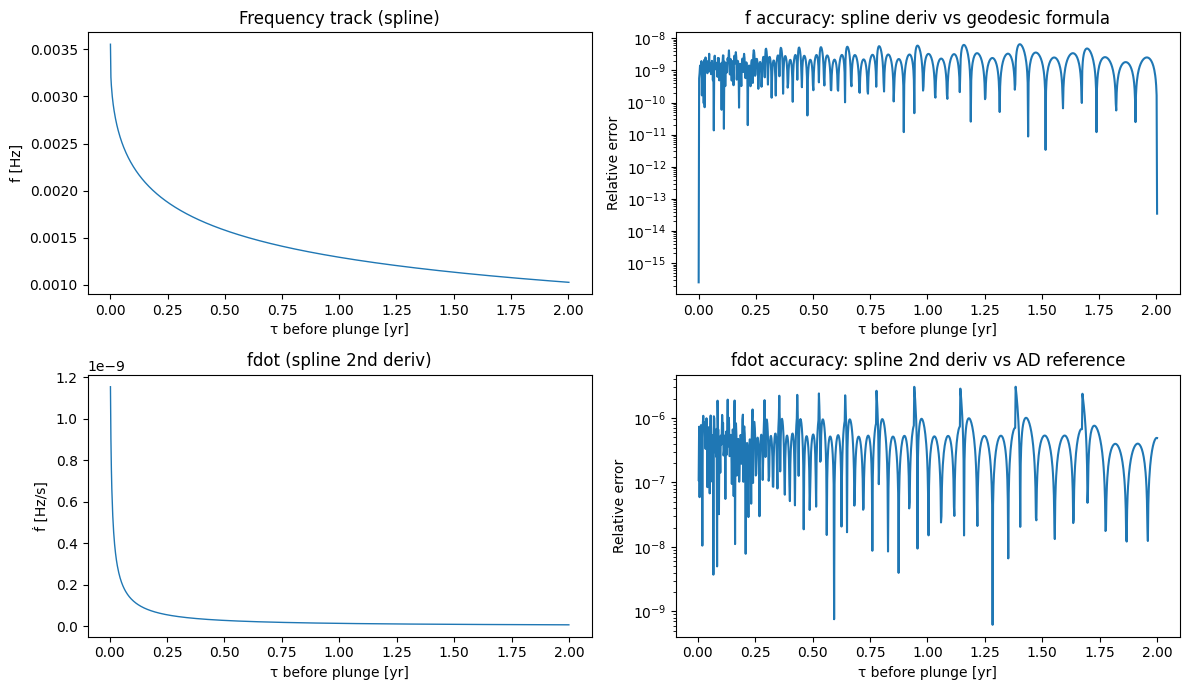


=== Results ===
  f  from spline 1st deriv:  accurate enough
  ḟ  from spline 2nd deriv:  accurate enough

  If fdot is not accurate, solve an augmented ODE that carries
  dOmega_phi/dt as an additional state variable (vector-field extension),
  yielding fdot directly without differentiating the interpolant twice.


In [41]:

# make plot
t_phys = tau_query * M_s   # [s] - physical time before plunge

# fdot is evaluated on an interior grid to avoid endpoint artifacts
edge_pad = 2
tau_query_fd = jnp.asarray(tau_query[edge_pad:-edge_pad], jnp.float64)
t_phys_fd = tau_query_fd * M_s

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].plot(t_phys / 3.15e7, np.array(f_spline), lw=1)
axes[0, 0].set(xlabel="τ before plunge [yr]", ylabel="f [Hz]", title="Frequency track (spline)")

axes[0, 1].semilogy(t_phys / 3.15e7, np.array(rel_err_f))
axes[0, 1].set(xlabel="τ before plunge [yr]", ylabel="Relative error",
               title="f accuracy: spline deriv vs geodesic formula")

axes[1, 0].plot(t_phys_fd / 3.15e7, np.array(fdot_spline), lw=1)
axes[1, 0].set(xlabel="τ before plunge [yr]", ylabel="ḟ [Hz/s]", title="fdot (spline 2nd deriv)")

axes[1, 1].semilogy(t_phys_fd / 3.15e7, np.array(rel_err_fd))
axes[1, 1].set(xlabel="τ before plunge [yr]", ylabel="Relative error",
               title="fdot accuracy: spline 2nd deriv vs AD reference")

plt.tight_layout()
plt.show()

# print out the results 
print("\n=== Results ===")
f_ok   = float(jnp.max(rel_err_f))  < 1e-6
fd_ok  = float(jnp.max(rel_err_fd)) < 1e-4
print(f"  f  from spline 1st deriv: {' accurate enough' if f_ok  else 'needs augmented ODE'}")
print(f"  ḟ  from spline 2nd deriv: {' accurate enough' if fd_ok else 'needs augmented ODE'}")
print(
    "\n  If fdot is not accurate, solve an augmented ODE that carries\n"
    "  dOmega_phi/dt as an additional state variable (vector-field extension),\n"
    "  yielding fdot directly without differentiating the interpolant twice."
)


### Add function to fewtrax trajectory module


In [42]:
def get_f_fdot_fddot_back(params, t_alpha):
    m1, m2, a, ef, Tpl = params
    x0 = 1.0
    rhs.add_fixed_parameters(m1, m2, a)
    p_0 = traj.inspiral_generator.func.separatrix_buffer_dist + get_separatrix(a, ef, x0) + 1e-6
    traj(m1, m2, a, p_0, ef, x0, T=Tpl, integrate_backwards=True, err=1e-11)

    T = np.min([Tpl, t_alpha[-1] / YRSID_SI])
    new_t_alpha = (t_alpha + YRSID_SI * T - t_alpha[-1])[::-1]
    mask = (new_t_alpha > 0.0)

    f = np.zeros((2, t_alpha.shape[0]))
    f_ = traj.inspiral_generator.eval_integrator_derivative_spline(new_t_alpha[mask], order=1)
    f[0][mask] = -f_[:, 3] / (np.pi * 2)
    f[1][mask] = -f_[:, 5] / (np.pi * 2)
    return f

In [43]:
sol_dense

Solution(
  t0=f64[],
  t1=f64[],
  ts=None,
  ys=None,
  interpolation=DenseInterpolation(
    ts=f64[513],
    ts_size=weak_i64[],
    infos={'k': f64[512,14,5], 'y0': f64[512,5], 'y1': f64[512,5]},
    interpolation_cls=diffrax._solver.dopri8._Dopri8Interpolation,
    direction=weak_i64[],
    t0_if_trivial=f64[],
    y0_if_trivial=f64[5]
  ),
  stats={
    'max_steps': 512,
    'num_accepted_steps': weak_i64[],
    'num_rejected_steps': weak_i64[],
    'num_steps': weak_i64[]
  },
  result=diffrax._solution.RESULTS<>,
  solver_state=None,
  controller_state=None,
  made_jump=None,
  event_mask=None
)

## Minimal working example: `EMRIInspiral.get_f_fdot_fddot_back`

The classmethod solves the backward ODE once with `SaveAt(dense=True)`, then
evaluates f, ḟ, f̈ on a fixed time grid via `jax.grad` on the Dopri8 dense
polynomial interpolant — no additional ODE solves needed.

**Time convention** (matching the original FEW function):
- `t_alpha[0] = 0` → observation start
- `t_alpha[-1] = T_obs * YEAR_SI` → plunge moment (τ = 0 in backward time)

In [47]:
import importlib
import fewtrax.trajectory.inspiral as _insp_mod
importlib.reload(_insp_mod)
from fewtrax.trajectory.inspiral import EMRIInspiral

# ── Parameters ───────────────────────────────────────────────────────────────
M_mwe    = 1e6      # primary mass [M_sun]
mu_mwe   = 10.0     # secondary mass [M_sun]
a_mwe    = 0.5      # BH spin
e_f_mwe  = 0.1      # eccentricity at plunge
T_mwe    = 2.0      # observation duration [years]
x0_mwe   = 1.0      # prograde

# Fixed time grid: 500 points from observation start to plunge
from fewtrax.utils.constants import YEAR_SI
N_alpha = 1200
t_alpha_mwe = np.linspace(0.0, T_mwe * YEAR_SI, N_alpha)   # [s]

# ── Call the classmethod ──────────────────────────────────────────────────────
f_mwe, fdot_mwe, fddot_mwe = EMRIInspiral.get_f_fdot_fddot_back(
    flux_data,          # pre-loaded in cell above
    M=M_mwe, mu=mu_mwe, a=a_mwe,
    e_f=e_f_mwe, T=T_mwe,
    t_alpha=t_alpha_mwe,
    x0=x0_mwe,
    max_steps=512, atol=1e-10, rtol=1e-10,
)

print("=== get_f_fdot_fddot_back output shapes ===")
print(f"  f     : {f_mwe.shape},  dtype={f_mwe.dtype}")
print(f"  fdot  : {fdot_mwe.shape},  dtype={fdot_mwe.dtype}")
print(f"  fddot : {fddot_mwe.shape},  dtype={fddot_mwe.dtype}")

print("\n=== Values at start / end of observation ===")
print(f"  f    [Hz]    :  start={float(f_mwe[0]):.6e}   plunge={float(f_mwe[-1]):.6e}")
print(f"  fdot [Hz/s]  :  start={float(fdot_mwe[0]):.6e}  plunge={float(fdot_mwe[-1]):.6e}")
print(f"  fddot[Hz/s²] :  start={float(fddot_mwe[0]):.6e} plunge={float(fddot_mwe[-1]):.6e}")

=== get_f_fdot_fddot_back output shapes ===
  f     : (1200,),  dtype=float64
  fdot  : (1200,),  dtype=float64
  fddot : (1200,),  dtype=float64

=== Values at start / end of observation ===
  f    [Hz]    :  start=1.027101e-03   plunge=3.553945e-03
  fdot [Hz/s]  :  start=5.747061e-12  plunge=1.076097e-06
  fddot[Hz/s²] :  start=1.063716e-19 plunge=5.662533e-08


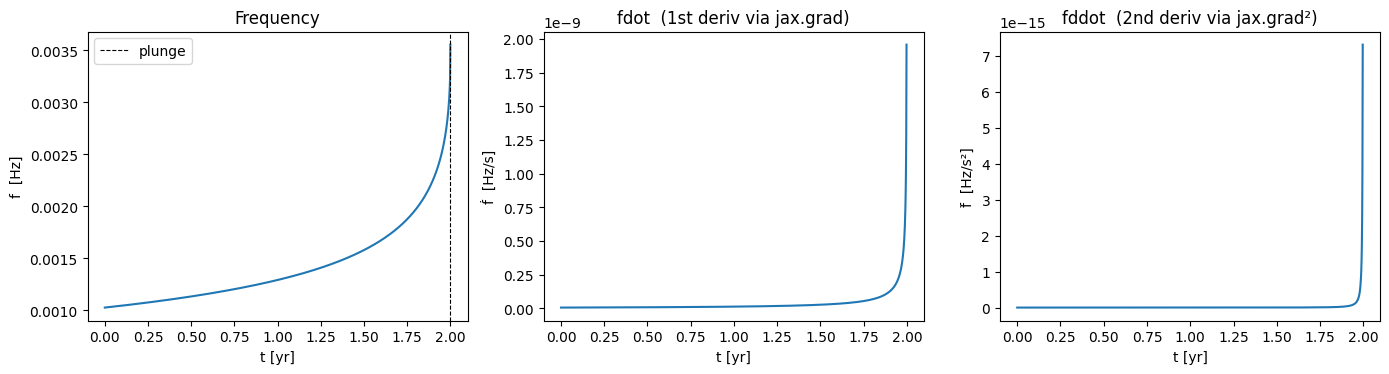

In [48]:
import matplotlib.pyplot as plt

t_yr = t_alpha_mwe / YEAR_SI   # time axis in years (0=start, T_mwe=plunge)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t_yr, np.array(f_mwe), lw=1.5)
axes[0].set(xlabel="t [yr]", ylabel="f  [Hz]", title="Frequency")
axes[0].axvline(T_mwe, ls="--", c="k", lw=0.8, label="plunge")
axes[0].legend()

axes[1].plot(t_yr[:-1], np.array(fdot_mwe)[:-1], lw=1.5)
axes[1].set(xlabel="t [yr]", ylabel="ḟ  [Hz/s]", title="fdot  (1st deriv via jax.grad)")

axes[2].plot(t_yr[:-2], np.array(fddot_mwe)[:-2], lw=1.5)
axes[2].set(xlabel="t [yr]", ylabel="f̈  [Hz/s²]", title="fddot  (2nd deriv via jax.grad²)")

plt.tight_layout()
plt.show()

## vmap over parameters

`get_f_fdot_fddot_back` is fully JAX-traceable (diffrax + jax.grad throughout), so
`jax.vmap` over any scalar parameter — here the BH spin `a` — works without
modification.  The inner vmap over `t_alpha` nests cleanly inside the outer one.

=== vmap output shapes ===
  f_batch     : (5, 1200)   (N_batch, N_alpha)
  fdot_batch  : (5, 1200)
  fddot_batch : (5, 1200)

=== f at plunge (t_alpha[-1]) for each spin ===
  a=0.1  →  f_plunge=2.414756e-03 Hz,  f_start=9.360145e-04 Hz
  a=0.3  →  f_plunge=2.874091e-03 Hz,  f_start=9.836281e-04 Hz
  a=0.5  →  f_plunge=3.553945e-03 Hz,  f_start=1.027101e-03 Hz
  a=0.7  →  f_plunge=4.696931e-03 Hz,  f_start=1.047043e-03 Hz
  a=0.9  →  f_plunge=7.328667e-03 Hz,  f_start=9.062570e-04 Hz

✓ f_plunge increases monotonically with a  (ISCO moves inward → higher frequency)


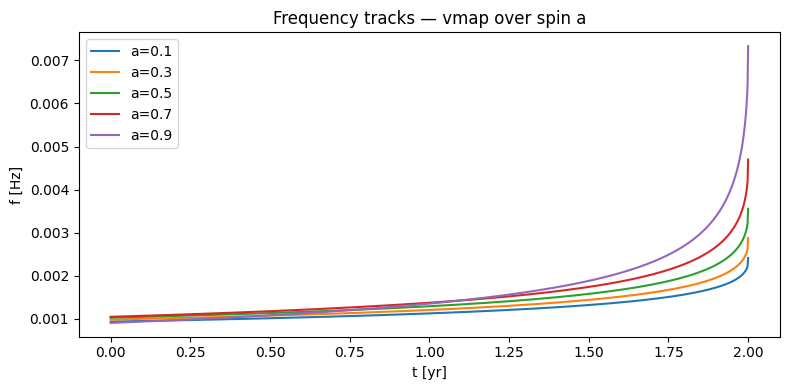

In [49]:
# Batch of 5 spins; all other params fixed
a_batch   = jnp.array([0.1, 0.3, 0.5, 0.7, 0.9])
e_f_batch = jnp.full(5, 0.1)

def track_for_params(a, e_f):
    """Thin wrapper — scalar (a, e_f) → (f, fdot, fddot) on t_alpha_mwe."""
    return EMRIInspiral.get_f_fdot_fddot_back(
        flux_data,
        M=M_mwe, mu=mu_mwe, a=a, e_f=e_f, T=T_mwe,
        t_alpha=t_alpha_mwe,
        max_steps=512, atol=1e-10, rtol=1e-10,
    )

# vmap over the batch dimension
f_batch, fdot_batch, fddot_batch = jax.vmap(track_for_params)(a_batch, e_f_batch)

print("=== vmap output shapes ===")
print(f"  f_batch     : {f_batch.shape}   (N_batch, N_alpha)")
print(f"  fdot_batch  : {fdot_batch.shape}")
print(f"  fddot_batch : {fddot_batch.shape}")

print("\n=== f at plunge (t_alpha[-1]) for each spin ===")
for i, a_val in enumerate(a_batch):
    print(f"  a={float(a_val):.1f}  →  f_plunge={float(f_batch[i, -1]):.6e} Hz,"
          f"  f_start={float(f_batch[i, 0]):.6e} Hz")

# Quick sanity: higher spin → higher ISCO frequency → higher f at plunge
assert jnp.all(jnp.diff(f_batch[:, -1]) > 0), "Expected f_plunge to increase with spin"
print("\n✓ f_plunge increases monotonically with a  (ISCO moves inward → higher frequency)")

# ── Plot all tracks ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for i, a_val in enumerate(a_batch):
    ax.plot(t_yr, np.array(f_batch[i]), label=f"a={float(a_val):.1f}")
ax.set(xlabel="t [yr]", ylabel="f [Hz]", title="Frequency tracks — vmap over spin a")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fdot_batch_sizes = [1, 4, 16, 64]
N_fdot_max = max(fdot_batch_sizes)

def build_fdot_param_grid(N: int, seed: int = 77) -> dict[str, np.ndarray]:
    """Draw N random EMRI parameter sets for backward f/fdot/fddot integration.

    ``e_f`` is the eccentricity at plunge — kept modest ([0.02, 0.40]) so that
    the separatrix is safely inside the flux-table domain for all spins.
    """
    rng = np.random.default_rng(seed)
    return dict(
        M   = 10.0 ** rng.uniform(np.log10(5e5), np.log10(5e6), N),
        mu  = rng.uniform(5.0, 50.0, N),
        a   = rng.uniform(0.05, 0.90, N),
        e_f = rng.uniform(0.02, 0.40, N),
    )

def print_header(title: str, width: int = 72) -> None:
    print()
    print("=" * width)
    print(f"  {title}")
    print("=" * width)

# import utility funcs from benchmark_vmap stuff
from comparison.benchmark_vmap_tracks import get_jax_memory_mb, get_peak_memory_mb
from comparison.utils import find_data_dir, block_jax, print_header, print_table, repeat_timer, get_cpu_memory_mb
def bench_f_fdot_fddot_back(
    flux_data,
    grid: dict,
    batch_sizes: list[int],
    n_warmup: int,
    n_repeat: int,
    T: float = 2.0,
    N_alpha: int = 1262,
    max_steps: int = 256,
    atol: float = 1e-10,
    rtol: float = 1e-10,
) -> list[dict]:
    """Benchmark vmapped ``EMRIInspiral.get_f_fdot_fddot_back``.

    Integrates backward from the plunge for ``T`` years, on a fixed
    ``N_alpha``-point time grid.  The dense Dopri8 interpolant is
    differentiated three times via ``jax.grad`` to recover f, ḟ, f̈
    without additional ODE solves.

    Memory note
    -----------
    ``SaveAt(dense=True)`` allocates k-coefficient buffers of shape
    ``(N_batch, max_steps, 14, 5)`` in float64.  Estimated size::

        N_batch * max_steps * 560 bytes

    For max_steps=256: 64 → 9 MB, 1024 → 143 MB, 8096 → 1.1 GB,
    65000 → 9.1 GB, 131066 → 18.3 GB.
    Reduce ``max_steps`` or split into sub-batches if memory is limited.
    """
    from fewtrax.trajectory.inspiral import EMRIInspiral
    from fewtrax.utils.constants import YEAR_SI

    # Fixed time grid shared across all batch lanes
    t_alpha = jnp.linspace(0.0, T * YEAR_SI, N_alpha, dtype=jnp.float64)

    def _track(a, e_f, M, mu):
        return EMRIInspiral.get_f_fdot_fddot_back(
            flux_data, M=M, mu=mu, a=a, e_f=e_f, T=T,
            t_alpha=t_alpha, max_steps=max_steps, atol=atol, rtol=rtol,
        )

    batched_fn = jax.jit(jax.vmap(_track))

    results = []
    for N in batch_sizes:
        a_b   = jnp.array(grid["a"][:N],   dtype=jnp.float64)
        e_f_b = jnp.array(grid["e_f"][:N], dtype=jnp.float64)
        M_b   = jnp.array(grid["M"][:N],   dtype=jnp.float64)
        mu_b  = jnp.array(grid["mu"][:N],  dtype=jnp.float64)

        # Estimated k-buffer memory for this batch [MiB]
        k_buf_mib = N * max_steps * 14 * 5 * 8 / 1024**2

        mem_before = get_jax_memory_mb()

        def fn():
            out = batched_fn(a_b, e_f_b, M_b, mu_b)
            block_jax(out)

        # Reduce repeats for very large batches to avoid excessive runtime
        nr = min(n_repeat, max(1, 3 if N <= 8096 else 1))
        nw = min(n_warmup, 1)
        mean_s, std_s = repeat_timer(fn, n_warmup=nw, n_repeat=nr)

        mem_after  = get_peak_memory_mb()
        throughput = N / mean_s

        results.append(dict(
            N=N, mean_s=mean_s, std_s=std_s,
            throughput=throughput,
            mem_peak_mb=mem_after,
            k_buf_mib=k_buf_mib,
        ))
        print(
            f"  N={N:7d}: {mean_s*1e3:10.1f} ± {std_s*1e3:7.1f} ms"
            f"  ({throughput:9.1f} tracks/s)"
            f"  k-buf≈{k_buf_mib:6.0f} MiB"
            f"  mem_peak={mem_after:.0f} MiB"
        )

    return results


fdot_grid = build_fdot_param_grid(N_fdot_max, seed=77)

T_fdot = 2.0
N_alpha = 1262
max_steps_fdot = 256

print_header(
    "get_f_fdot_fddot_back: vmapped backward ODE + jax.grad³"
)
print(f"   T={T_fdot} yr backward  |  N_alpha={N_alpha} pts"
        f"  |  max_steps={max_steps_fdot}")
print(f"   k-buffer per trajectory ≈"
        f" {max_steps_fdot * 14 * 5 * 8 / 1024:.0f} KB  "
        f"(N_batch × max_steps × 14 × 5 × 8 bytes)")
print(f"   Batch sizes: {fdot_batch_sizes}")
print(f"   WARNING: N≥65000 requires >9 GB of k-buffer memory "
        f"(reduce --max-steps-fdot if needed)")
print()

print(f"  Building fdot parameter grid  (N={N_fdot_max}, seed=77) …",
        end=" ", flush=True)
fdot_grid = build_fdot_param_grid(N_fdot_max, seed=77)
print("done")
print(f"  a   range : [{fdot_grid['a'].min():.3f},  {fdot_grid['a'].max():.3f}]")
print(f"  e_f range : [{fdot_grid['e_f'].min():.3f}, {fdot_grid['e_f'].max():.3f}]")
print(f"  M   range : [{fdot_grid['M'].min():.2e}, {fdot_grid['M'].max():.2e}] Msun")
print(f"  mu  range : [{fdot_grid['mu'].min():.1f}, {fdot_grid['mu'].max():.1f}] Msun")
print()

nw, nr = 5, 5
fdot_results = bench_f_fdot_fddot_back(
    flux_data, fdot_grid,
    batch_sizes=fdot_batch_sizes,
    n_warmup=nw, n_repeat=nr,
    T=T_fdot, N_alpha=N_alpha,
    max_steps=max_steps_fdot,
)

print()
fd_headers = ["N_batch", "wall time [ms]", "throughput [tracks/s]", "k-buf [MiB]"]
fd_widths  = [10, 22, 24, 14]
fd_rows = [
    (
        str(r["N"]),
        f"{r['mean_s']*1e3:.1f} ± {r['std_s']*1e3:.1f}",
        f"{r['throughput']:.1f}",
        f"{r['k_buf_mib']:.0f}",
    )
    for r in fdot_results
]
print_table(fd_rows, fd_headers, fd_widths)



  D. get_f_fdot_fddot_back — vmapped backward ODE + jax.grad³
   T=2.0 yr backward  |  N_alpha=1262 pts  |  max_steps=256
   k-buffer per trajectory ≈ 140 KB  (N_batch × max_steps × 14 × 5 × 8 bytes)
   Batch sizes: [1, 4, 16, 64]

  Building fdot parameter grid  (N=64, seed=77) … done
  a   range : [0.077,  0.900]
  e_f range : [0.022, 0.387]
  M   range : [5.03e+05, 4.75e+06] Msun
  mu  range : [5.9, 49.7] Msun



NameError: name 'nw' is not defined

In [ ]:
m1, m2 = 1e6, 10.0
a, e0, x0 = 0.5, 0.10, 1.0
T    = 1.0    # observation time [yr]
dt   = 1000.0 # cadence [s]
dist = 1.0    # luminosity distance [Gpc]
theta, phi = np.pi / 3, np.pi / 3  # observer angles for Ylm

# Backward integration from the separatrix to find the initial p0, e0.
p0_sep = traj.inspiral_generator.func.separatrix_buffer_dist + get_separatrix(a, e0, x0) + 1e-6
, p_back, e_back, * = traj(m1, m2, a, p0_sep, e0, x0, T=T, integrate_backwards=True)

# Forward trajectory from the backward-integrated initial conditions.
t_traj, p_arr, e_arr, x_arr, Phi_phi_traj, Phi_theta_traj, Phi_r_traj = traj(m1, m2, a, p_back[-1], e_back[-1], x0, T=T)

# Amplitudes at each sparse trajectory point (GPU → numpy via model.xp).
teuk_modes = model.amplitude_generator(a, model.xp.asarray(p_arr), model.xp.asarray(e_arr), x0)

# Ylms for every (l, m) pair in the model's mode set.
ylms_full = model.ylm_gen(model.unique_l, model.unique_m, theta, phi)[model.inverse_lm]

# Mode selection — stable FEW 2.0.0 API:
# ModeSelector(l_arr, m_arr, n_arr, ...) at init (done inside model)
# call(teuk_modes, ylms, modeinds, fund_freq_args=...) at runtime
# returns (teuk_sel, ylms_sel, ls, ms, ns) — no ks; equatorial ⇒ k=0
modeinds      = [model.l_arr, model.m_arr, model.n_arr]
fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p_arr),
                  model.xp.asarray(e_arr),
                  model.xp.asarray(x_arr),
                  model.xp.asarray(t_traj))

teuk_sel, ylms_sel, ls, ms, ns = model.mode_selector(
    teuk_modes, ylms_full, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
 )

teuk = jnp.asarray(teuk_sel)   # (n_t, n_m) complex128
ylms = jnp.asarray(ylms_sel)   # (2*n_m,)   complex128
ls   = jnp.asarray(ls)
ms   = jnp.asarray(ms)
ns   = jnp.asarray(ns)
ks   = jnp.zeros_like(ls)      # equatorial orbit: k = 0 for all modes

n_t_traj, n_m = teuk.shape
print(f"trajectory grid : n_t={n_t_traj}, n_m={n_m}")